# Quantitative Risk Management Assignment

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, json, pathlib
import kagglehub
from pathlib import Path
import re

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report

In [ ]:
path = kagglehub.dataset_download("uciml/default-of-credit-card-clients-dataset")
print("Path to dataset files:", path)

100%|██████████| 0.98M/0.98M [00:00<00:00, 1.92MB/s]

Extracting files...
Path to dataset files: /Users/sebastianuedingslohmann/.cache/kagglehub/datasets/uciml/default-of-credit-card-clients-dataset/versions/1


In [16]:
# Load dataset and save as df
base = Path(path)
df = pd.read_csv(base / "UCI_Credit_Card.csv")

In [17]:
print(df.shape)

(30000, 25)


In [19]:
display(df.head())

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

In [29]:
# Change column name of target variable
df = df.rename(columns={"default.payment.next.month": "default"})
df = df.drop(columns=["ID"])
df.columns = [re.sub(r"[^\w]", "_", c).strip("_").lower() for c in df.columns]

# Check if target variable has only 0 and 1 values
assert set(df['default'].unique()) == {0, 1}

In [32]:
cat_checks = {}
cat_checks['sex'] = df['sex'].value_counts(dropna = False).sort_index()
cat_checks['education'] = df['education'].value_counts(dropna = False).sort_index()
cat_checks['marriage'] = df['marriage'].value_counts(dropna = False).sort_index()

pay_cols = [c for c in df.columns if re.fullmatch(r"pay_[0-6]", c)]
pay_counts = {c: df[c].value_counts(dropna = False).sort_index() for c in pay_cols}

In [47]:
# Ensure cat_checks and pay_counts are defined
cat_checks = {}
cat_checks['sex'] = df['sex'].value_counts(dropna=False).sort_index()
cat_checks['education'] = df['education'].value_counts(dropna=False).sort_index()
cat_checks['marriage'] = df['marriage'].value_counts(dropna=False).sort_index()

pay_cols = [c for c in df.columns if re.fullmatch(r"pay_[0-6]", c)]
pay_counts = {c: df[c].value_counts(dropna=False).sort_index() for c in pay_cols}

print("Category checks (SEX / EDUCATION / MARRIAGE):")
for k, v in cat_checks.items():
    print(f"\n{k.upper()}:\n{v}")

print("\nPAY_* Value range (should be -2..8):")
for c, vc in pay_counts.items():
    print(f"\n{c}:\n{vc.head(20)}")

Category checks (SEX / EDUCATION / MARRIAGE):

SEX:
sex
1    11888
2    18112
Name: count, dtype: int64

EDUCATION:
education
1    10585
2    14030
3     4917
4      468
Name: count, dtype: int64

MARRIAGE:
marriage
1    13659
2    15964
3      377
Name: count, dtype: int64

PAY_* Value range (should be -2..8):

pay_0:
pay_0
-2     2759
-1     5686
 0    14737
 1     3688
 2     2667
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19
Name: count, dtype: int64

pay_2:
pay_2
-2     3782
-1     6050
 0    15730
 1       28
 2     3927
 3      326
 4       99
 5       25
 6       12
 7       20
 8        1
Name: count, dtype: int64

pay_3:
pay_3
-2     4085
-1     5938
 0    15764
 1        4
 2     3819
 3      240
 4       76
 5       21
 6       23
 7       27
 8        3
Name: count, dtype: int64

pay_4:
pay_4
-2     4348
-1     5687
 0    16455
 1        2
 2     3159
 3      180
 4       69
 5       35
 6        5
 7       58
 8        2
Name: count, dtype: int64

In [46]:
marriage_map = {0: 3, 4: 3, 5: 3, 6: 3, 7: 3, 8: 3}
df["marriage"] = df["marriage"].replace(marriage_map).astype("int64")
print(df['marriage'].value_counts().sort_index())

marriage
1    13659
2    15964
3      377
Name: count, dtype: int64


In [45]:
edu_map_to_other = {0: 4, 5: 4, 6: 4}
df["education"] = df["education"].replace(edu_map_to_other).astype("int64")
print(df['education'].value_counts().sort_index())

education
1    10585
2    14030
3     4917
4      468
Name: count, dtype: int64


In [51]:
if "sex_cat" not in df and "sex" in df:
    df["sex_cat"] = df["sex"].map({1: "male", 2: "female"}).astype("category")
if "education_cat" not in df and "education" in df:
    df["education_cat"] = df["education"].map({1:"graduate_school",2:"university",3:"high_school",4:"other"}).astype("category")
if "marriage_cat" not in df and "marriage" in df:
    df["marriage_cat"] = df["marriage"].map({1:"married",2:"single",3:"other"}).astype("category")

# 2) One-Hot direkt in df (0/1 statt True/False), Referenzkategorie droppen
cat_cols = [c for c in ["sex_cat","education_cat","marriage_cat"] if c in df.columns]
dummies = pd.get_dummies(df[cat_cols], drop_first=True, dtype="int8")

# 3) Original-*_cat-Spalten entfernen und Dummies anhängen
df = pd.concat([df.drop(columns=cat_cols), dummies], axis=1)


In [57]:
pay_cols = [c for c in df.columns if re.fullmatch(r"pay_[0-6]", c)]

for c in pay_cols:
    orig = df[c].astype("int64")
    idx = c.split("_")[1]  # '0','2','3',...
    
    df[f"paid_in_full_{idx}"] = (orig == -1).astype("int8")
    
    ml = orig.clip(lower=0).where(orig < 7, 6).astype("int8")
    df[f"months_late_{idx}"] = ml

df = df.drop(columns=pay_cols)

new_cols = sorted([c for c in df.columns if re.fullmatch(r"(paid_in_full|months_late)_[0-6]", c)])
print("Newly created PAY features:", new_cols)
display(df[new_cols].head(3))

Newly created PAY features: ['months_late_0', 'months_late_2', 'months_late_3', 'months_late_4', 'months_late_5', 'months_late_6', 'paid_in_full_0', 'paid_in_full_2', 'paid_in_full_3', 'paid_in_full_4', 'paid_in_full_5', 'paid_in_full_6']


,months_late_0,months_late_2,months_late_3,months_late_4,months_late_5,months_late_6,paid_in_full_0,paid_in_full_2,paid_in_full_3,paid_in_full_4,paid_in_full_5,paid_in_full_6
0,2,2,0,0,0,0,0,0,1,1,0,0
1,0,2,0,0,0,2,1,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0


In [59]:
df.drop(columns = ['sex', 'education', 'marriage'], inplace = True)

In [60]:
df.columns

Index(['limit_bal', 'age', 'bill_amt1', 'bill_amt2', 'bill_amt3', 'bill_amt4',
       'bill_amt5', 'bill_amt6', 'pay_amt1', 'pay_amt2', 'pay_amt3',
       'pay_amt4', 'pay_amt5', 'pay_amt6', 'default', 'sex_cat_male',
       'education_cat_high_school', 'education_cat_other',
       'education_cat_university', 'marriage_cat_other', 'marriage_cat_single',
       'paid_in_full_0', 'months_late_0', 'paid_in_full_2', 'months_late_2',
       'paid_in_full_3', 'months_late_3', 'paid_in_full_4', 'months_late_4',
       'paid_in_full_5', 'months_late_5', 'paid_in_full_6', 'months_late_6'],
      dtype='object')

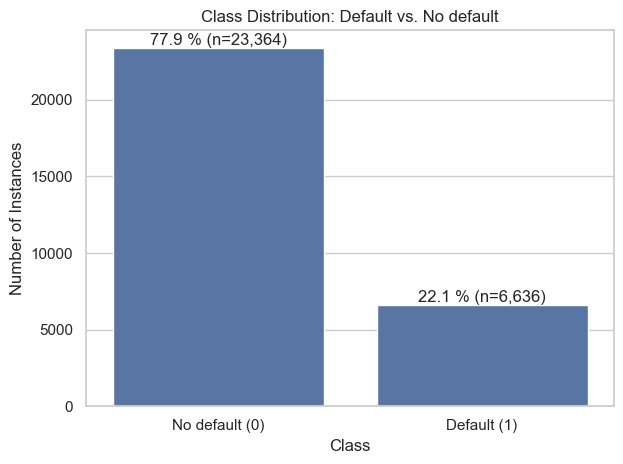

In [ ]:
# Visualize the class imbalance in a barplot
sns.set_theme(style="whitegrid")

counts = df["default"].value_counts().sort_index()
pcts   = (df["default"].value_counts(normalize=True)
         .sort_index()
         .mul(100).round(1))

labels = ["No default (0)", "Default (1)"]

ax = sns.barplot(x=labels, y=counts.values)
ax.set_xlabel("Class")
ax.set_ylabel("Number of Instances")
ax.set_title("Class Distribution: Default vs. No default")

for i, (n, p) in enumerate(zip(counts.values, pcts.values)):
    ax.text(i, n, f"{p} % (n={n:,})", ha="center", va="bottom")

plt.tight_layout()
plt.show()

In [64]:
# 1) No Nas
assert df.isna().sum().sum() == 0, "Es gibt noch fehlende Werte."

# 2) Target is binary 0/1
assert set(df["default"].unique()) <= {0,1}, "Target ist nicht binär."

# 3) Dummies are 0/1
dummy_cols = [c for c in df.columns if c.startswith(("sex_cat_","education_cat_","marriage_cat_","paid_in_full_"))]
for c in dummy_cols:
    vals = set(df[c].unique())
    assert vals <= {0,1}, f"{c} ist nicht strikt binär: {vals}"

# 4) months_late in 0..6 (binned)
ml_cols = [c for c in df.columns if c.startswith("months_late_")]
for c in ml_cols:
    lo, hi = df[c].min(), df[c].max()
    assert 0 <= lo <= hi <= 6, f"{c} hat Werte außerhalb 0..6: [{lo},{hi}]"

print("Checks passed. Rows/Cols:", df.shape)


Checks passed. Rows/Cols: (30000, 33)


In [66]:
y = df["default"].astype("int64")
X = df.drop(columns=["default"])

In [68]:
dummy_prefixes = ("sex_cat_","education_cat_","marriage_cat_","paid_in_full_")
cols_to_scale = [c for c in X.columns if not c.startswith(dummy_prefixes)]

In [67]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state=42, stratify = y)

In [70]:
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

In [71]:
X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test_scaled[cols_to_scale]  = scaler.transform(X_test[cols_to_scale])

In [72]:
model = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [73]:
proba = model.predict_proba(X_test_scaled)[:, 1]
pred  = (proba >= 0.5).astype(int)

In [74]:
print("ROC-AUC:", round(roc_auc_score(y_test, proba), 4))
print("\nConfusion matrix:\n", confusion_matrix(y_test, pred))
print("\nReport:\n", classification_report(y_test, pred, digits=3))

ROC-AUC: 0.7522

Confusion matrix:
 [[3923  750]
 [ 589  738]]

Report:
               precision    recall  f1-score   support

           0      0.869     0.840     0.854      4673
           1      0.496     0.556     0.524      1327

    accuracy                          0.777      6000
   macro avg      0.683     0.698     0.689      6000
weighted avg      0.787     0.777     0.781      6000

